### Importaciones y selección del Dataset

In [ ]:
!pip install transformers datasets evaluate scikit-learn matplotlib seaborn -q
!pip install accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.2 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
import random
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as npg
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from transformers import TrainingArguments, Trainer

In [ ]:
# Cargar el dataset TweetEval, subtarea: sentiment
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

print("✅ Dataset cargado correctamente")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Dataset cargado correctamente
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


#### Descripción del dataset

**TweetEval** es un benchmark unificado para la evaluación de modelos de PLN sobre texto de Twitter. Fue propuesto en el paper *"TweetEval: Unified Benchmark and Comparative Evaluation for Tweet Classification"* (Barbieri et al., 2020)

[Dataset Hugging Face](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest
)

**Dominio:** Redes sociales / Análisis de opinión pública

**Problema:** Determinar la polaridad emocional de un tweet escrito en inglés

**Utilidad práctica:**
  - Monitoreo de marca (¿qué dice la gente de un producto?)
  - Análisis de tendencias políticas o sociales
  - Detección temprana de crisis o insatisfacción de clientes
  - Apoyo a estudios de mercado

### Datos de entrada y salida

| Campo | Descripción |
|---|---|
| **Entrada (X)** | Texto de un tweet (cadena de caracteres, máx. ~280 chars) |
| **Salida (Y)** | Etiqueta de sentimiento: `0 = Negativo`, `1 = Neutro`, `2 = Positivo` |

### Tipo de problema de PLN
- **Tarea:** *Sequence Classification* (clasificación de secuencias)
- **Subcategoría:** Análisis de sentimientos (*Sentiment Analysis*)
- **Número de clases:** 3 (multiclase)

### Splits del dataset

| Split | Ejemplos |
|---|---|
| Train | 45,615 |
| Validation | 2,000 |
| Test | 12,284 |

In [ ]:
print("=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)
for split_name, split_data in dataset.items():
    print(f"\n Split: {split_name}")
    print(f"   Número de ejemplos: {len(split_data)}")
    print(f"   Características: {split_data.features}")

label_names = dataset["train"].features["label"].names
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for idx, label in enumerate(label_names)}

print("\n Etiquetas:")
for idx, name in id2label.items():
    print(f"   {idx} → {name}")

INFORMACIÓN DEL DATASET

 Split: train
   Número de ejemplos: 45615
   Características: {'text': Value('string'), 'label': ClassLabel(names=['negative', 'neutral', 'positive'])}

 Split: test
   Número de ejemplos: 12284
   Características: {'text': Value('string'), 'label': ClassLabel(names=['negative', 'neutral', 'positive'])}

 Split: validation
   Número de ejemplos: 2000
   Características: {'text': Value('string'), 'label': ClassLabel(names=['negative', 'neutral', 'positive'])}

 Etiquetas:
   0 → negative
   1 → neutral
   2 → positive


### Análisis Exploratorio de Datos (EDA)

Ejemplos reales por clase (negativo / neutro / positivo)

In [ ]:
print("EJEMPLOS DEL DATASET POR CLASE\n")
print("=" * 60)

for label_id, label_name in id2label.items():
    ejemplos = [ex for ex in dataset["train"] if ex["label"] == label_id]
    muestra = random.sample(ejemplos, min(3, len(ejemplos)))

    print(f"\n Clase {label_id} — '{label_name.upper()}'")
    print("-" * 50)
    for i, ex in enumerate(muestra, 1):
        print(f"  [{i}] {ex['text']}")

EJEMPLOS DEL DATASET POR CLASE


 Clase 0 — 'NEGATIVE'
--------------------------------------------------
  [1] Why the hell is Black Friday by j cole and Kendrick not on iTunes yet.
  [2] not a damn thing went the way of the Red Sox tonight and that's baseball and that's life.   win the series tomorrow.
  [3] "#JohnKerry says #ISIS had a ""rationale"" for the Charlie Hebdo killings in January (pic of Muhammad), but Friday night in Paris was different"

 Clase 1 — 'NEUTRAL'
--------------------------------------------------
  [1] @user @user @user @user The Open - Leaderboard love it hope Paul Dunne is top tomorrow?
  [2] @user Have you heard of Bobby Jindal? 1st Indian American Governor of Louisiana, USA. Doesn't identify as 'Indian'.
  [3] 100-strong Azerbaijani economic delegation to visit Iran: Azerbaijan was the 12th leading importer of Iranian ...

 Clase 2 — 'POSITIVE'
--------------------------------------------------
  [1] The new Moto G may be the best budget phone... again. 

Gráficos de distribución de clases (barras + torta)

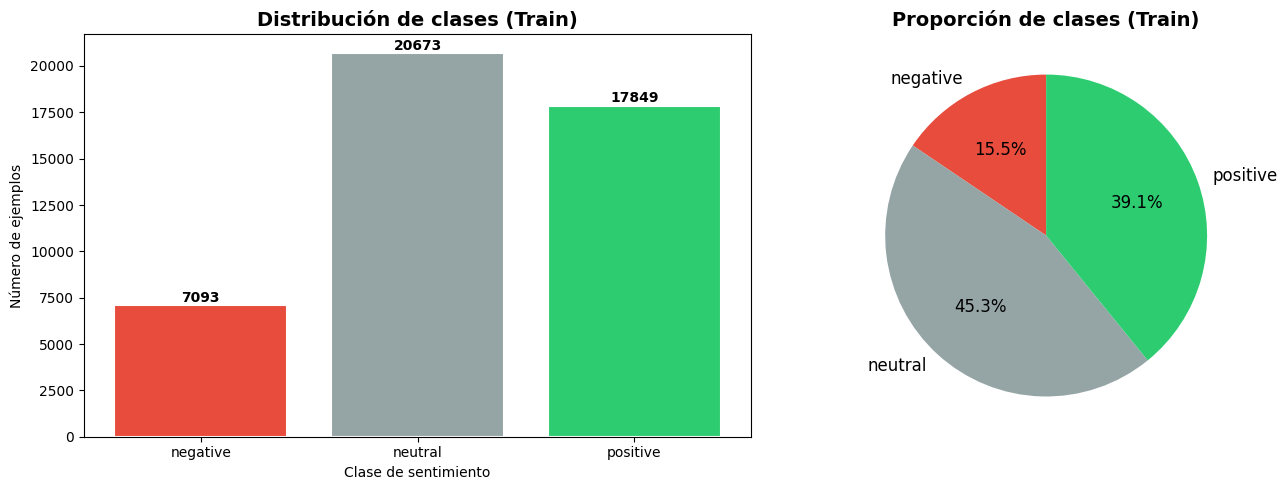

💡 Observación: El dataset está desbalanceado — hay más tweets positivos que negativos.


In [ ]:
labels_train = dataset["train"]["label"]
conteo = Counter(labels_train)
clases = [id2label[k] for k in sorted(conteo.keys())]
valores = [conteo[k] for k in sorted(conteo.keys())]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colores = ["#e74c3c", "#95a5a6", "#2ecc71"]
axes[0].bar(clases, valores, color=colores, edgecolor="white", linewidth=1.5)
axes[0].set_title("Distribución de clases (Train)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Clase de sentimiento")
axes[0].set_ylabel("Número de ejemplos")
for i, (clase, val) in enumerate(zip(clases, valores)):
    axes[0].text(i, val + 200, str(val), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(valores, labels=clases, colors=colores, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title("Proporción de clases (Train)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 Observación: El dataset está desbalanceado — hay más tweets positivos que negativos.")

Histograma de longitud de tweets


📏 ESTADÍSTICAS DE LONGITUD DE TWEETS (en palabras)
----------------------------------------
  Mínimo:   1 palabras
  Máximo:   35 palabras
  Media:    19.2 palabras
  Mediana:  20 palabras
  Std Dev:  4.9


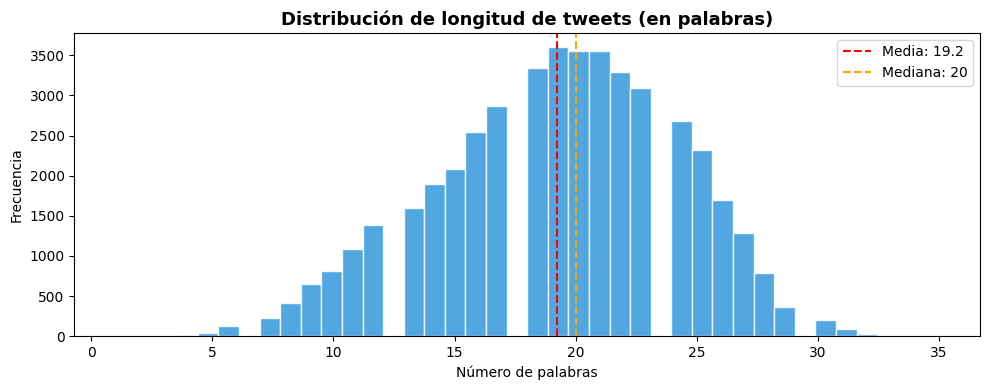

In [ ]:
longitudes = [len(text.split()) for text in dataset["train"]["text"]]

print("📏 ESTADÍSTICAS DE LONGITUD DE TWEETS (en palabras)")
print("-" * 40)
print(f"  Mínimo:   {np.min(longitudes)} palabras")
print(f"  Máximo:   {np.max(longitudes)} palabras")
print(f"  Media:    {np.mean(longitudes):.1f} palabras")
print(f"  Mediana:  {np.median(longitudes):.0f} palabras")
print(f"  Std Dev:  {np.std(longitudes):.1f}")

plt.figure(figsize=(10, 4))
plt.hist(longitudes, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(longitudes), color='red', linestyle='--', label=f'Media: {np.mean(longitudes):.1f}')
plt.axvline(np.median(longitudes), color='orange', linestyle='--', label=f'Mediana: {np.median(longitudes):.0f}')
plt.title("Distribución de longitud de tweets (en palabras)", fontsize=13, fontweight='bold')
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.savefig("longitud_tweets.png", dpi=150, bbox_inches='tight')
plt.show()

Top 15 palabras más frecuentes por clase



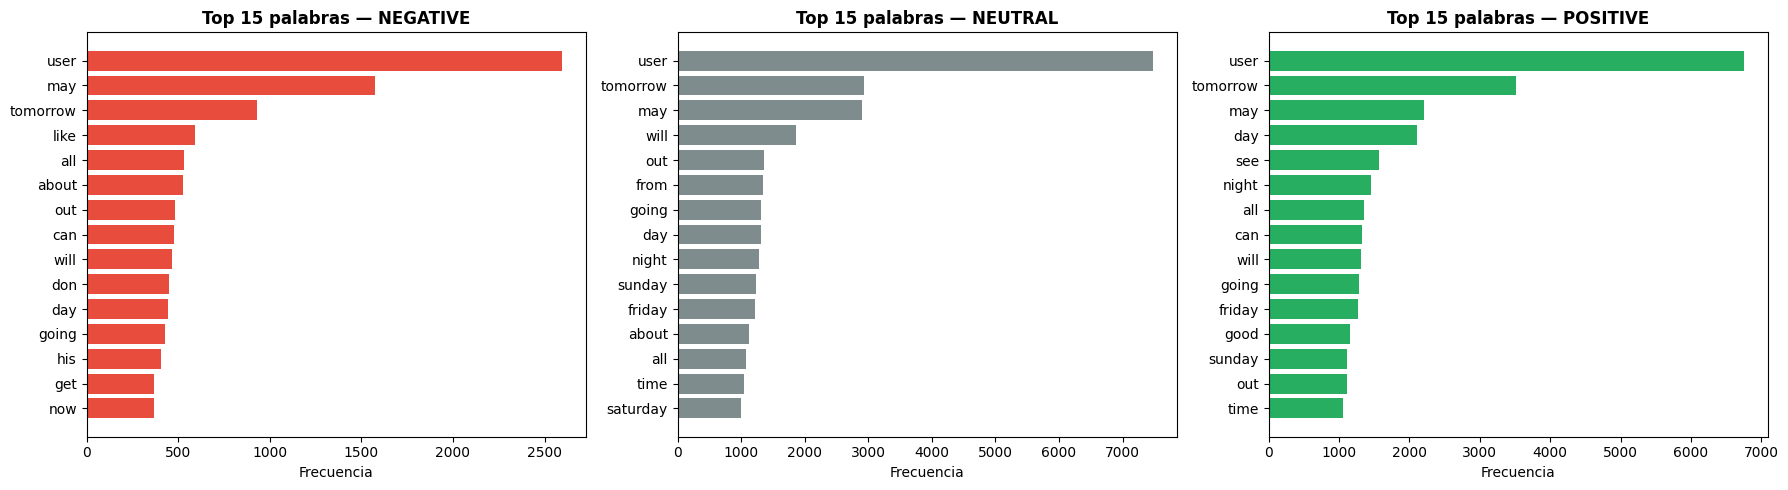

In [ ]:
stopwords = set(["the", "a", "an", "is", "it", "i", "to", "and", "of",
                 "in", "this", "that", "my", "for", "on", "at", "are",
                 "be", "was", "with", "you", "so", "do", "me", "he",
                 "she", "we", "they", "but", "not", "have", "has", "had",
                 "its", "just", "im", "rt", "amp"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores_bar = ["#e74c3c", "#7f8c8d", "#27ae60"]

for label_id, label_name in id2label.items():
    textos = [ex["text"].lower() for ex in dataset["train"] if ex["label"] == label_id]
    palabras = []
    for t in textos:
        tokens = re.findall(r'\b[a-z]{3,}\b', t)
        palabras.extend([tok for tok in tokens if tok not in stopwords])

    top20 = Counter(palabras).most_common(15)
    words, counts = zip(*top20)

    axes[label_id].barh(list(reversed(words)), list(reversed(counts)),
                        color=colores_bar[label_id])
    axes[label_id].set_title(f"Top 15 palabras — {label_name.upper()}",
                              fontsize=12, fontweight='bold')
    axes[label_id].set_xlabel("Frecuencia")

plt.tight_layout()
plt.savefig("palabras_frecuentes.png", dpi=150, bbox_inches='tight')
plt.show()

---
### Preparación del Modelo y Tokenización

Se usará **`bert-base-uncased`** como modelo base. BERT (*Bidirectional Encoder Representations from Transformers*) es un modelo preentrenado de Google que utiliza atención bidireccional sobre el texto. Lo ajustaremos (fine-tuning) para nuestra tarea de clasificación de sentimientos.

**¿Por qué BERT?**
- Preentrenado sobre Wikipedia y BooksCorpus (gran corpus general)
- Bidireccional: entiende el contexto completo de cada palabra
- Excelente punto de partida para tareas de clasificación de texto
- Amplio soporte en la comunidad HuggingFace

In [ ]:
MODEL_NAME = "bert-base-uncased"
NUM_LABELS = 3
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device.upper()}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Dispositivo: CUDA


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print("\n📊 Ejemplo tokenizado:")

ejemplo = tokenized_dataset["train"][0]

print(f"   input_ids length: {len(ejemplo['input_ids'])}")
print(f"   attention_mask length: {len(ejemplo['attention_mask'])}")
print(f"   label: {ejemplo['label']} → {id2label[ejemplo['label']]}")


📊 Ejemplo tokenizado:
   input_ids length: 128
   attention_mask length: 128
   label: 2 → positive


In [ ]:
# -------------------------------------------------------
# Visualización del dataset tokenizado
# -------------------------------------------------------
print("=" * 60)
print("VISTA DEL DATASET TOKENIZADO")
print("=" * 60)

# Ver la estructura general
print(f"\n📦 Estructura: {tokenized_dataset}")

# Tomar el primer ejemplo del split de entrenamiento
ejemplo = tokenized_dataset["train"][0]

print(f"\n{'─'*60}")
print("📝 EJEMPLO #1 DEL TRAIN")
print(f"{'─'*60}")

# Texto original
print(f"\n🔤 Texto original:")
print(f"   '{dataset['train'][0]['text']}'")

# Etiqueta
label_id = ejemplo["label"]
print(f"\n🏷️ Etiqueta: {label_id} → {id2label[label_id].upper()}")

# input_ids
print(f"\n🔢 input_ids (longitud: {len(ejemplo['input_ids'])}):")
print(f"   {ejemplo['input_ids']}")

# Decodificación token por token
tokens = tokenizer.convert_ids_to_tokens(ejemplo["input_ids"])

print(f"\n🔡 Tokens decodificados:")
print(f"   {tokens}")

# Attention mask
print(f"\n🎭 Attention mask:")
print(f"   {ejemplo['attention_mask']}")

# Cuántos tokens son reales vs padding
n_reales = sum(ejemplo["attention_mask"])
n_padding = len(ejemplo["attention_mask"]) - n_reales

print(f"\n📊 Tokens reales: {n_reales} | Tokens [PAD]: {n_padding}")

# -------------------------------------------------------
# Resumen de los primeros ejemplos
# -------------------------------------------------------
print(f"\n{'─'*60}")
print("📋 RESUMEN — PRIMEROS 5 EJEMPLOS")
print(f"{'─'*60}")

print(f"{'#':<5} {'Tokens reales':<15} {'Label':<10} {'Texto'}")
print(f"{'─'*60}")

for i in range(5):
    ej = tokenized_dataset["train"][i]

    texto = dataset["train"][i]["text"][:50]
    reales = sum(ej["attention_mask"])
    label = id2label[ej["label"]]

    print(
        f"{i:<5} "
        f"{reales:<15} "
        f"{label:<10} "
        f"'{texto}...'"
    )

VISTA DEL DATASET TOKENIZADO

📦 Estructura: DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

────────────────────────────────────────────────────────────
📝 EJEMPLO #1 DEL TRAIN
────────────────────────────────────────────────────────────

🔤 Texto original:
   '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"'

🏷️ Etiqueta: 2 → POSITIVE

🔢 input_ids (longitud: 128):
   [101, 1000, 1053, 2102, 1030, 5310, 1999, 1996, 2434, 4433, 1997, 1996, 5504, 2338, 1010, 2128, 7606, 11320, 8091, 5175, 1996, 2645, 1997, 27589, 18367, 2015, 1012, 1001, 3

---
### Fine-Tuning con diferentes hiperparámetros

Entrenaremos el modelo **3 veces** variando el **learning rate** (tasa de aprendizaje), que es el hiperparámetro más importante en fine-tuning de transformers.

| Experimento | Learning Rate | Épocas | Descripción |
|---|---|---|---|
| Exp. 1 | `5e-5` | 3 | LR alto — aprende rápido, puede sobreajustar |
| Exp. 2 | `2e-5` | 3 | LR estándar — recomendado para BERT |
| Exp. 3 | `5e-6` | 3 | LR conservador — aprendizaje lento y estable |



In [ ]:
import evaluate
import numpy as np

# -------------------------------------------------------
# Métricas de evaluación
# -------------------------------------------------------
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """
    Calcula accuracy y F1-macro a partir de las predicciones.
    F1-macro es preferido cuando las clases están desbalanceadas.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

print("✅ Métricas configuradas: Accuracy + F1-Macro")

✅ Métricas configuradas: Accuracy + F1-Macro


In [ ]:
from transformers import TrainingArguments, Trainer
from datasets import Dataset

# Para usar el dataset completo, cambia N_TRAIN a len(tokenized_dataset["train"])
N_TRAIN = 10000
N_EVAL = 2000

train_subset = tokenized_dataset["train"].select(range(N_TRAIN))
eval_subset  = tokenized_dataset["validation"].select(range(N_EVAL))
test_data    = tokenized_dataset["test"]

print(f"📊 Split de entrenamiento: {len(train_subset)} ejemplos")
print(f"📊 Split de validación:   {len(eval_subset)} ejemplos")
print(f"📊 Split de test:         {len(test_data)} ejemplos")

📊 Split de entrenamiento: 10000 ejemplos
📊 Split de validación:   2000 ejemplos
📊 Split de test:         12284 ejemplos


In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

def entrenar_experimento(learning_rate, num_epochs, output_dir, experiment_name):
    print(f"\n{'='*55}")
    print(f"🚀 {experiment_name}")
    print(f"   Learning Rate : {learning_rate}")
    print(f"   Épocas        : {num_epochs}")
    print(f"{'='*55}")

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        weight_decay=0.01,
        warmup_ratio=0.1,

        # Fix: nombre actualizado en versiones recientes
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",

        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        eval_dataset=eval_subset,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )

    trainer.train()
    resultados = trainer.evaluate()

    print(f"\n📈 Accuracy : {resultados['eval_accuracy']:.4f}")
    print(f"📈 F1-Macro : {resultados['eval_f1_macro']:.4f}")

    return trainer, resultados

#### Experimentos

In [ ]:
trainer_exp1, resultados_exp1 = entrenar_experimento(
    learning_rate=5e-5,
    num_epochs=3,
    output_dir="./resultados/exp1_lr5e5",
    experiment_name="Experimento 1 — LR: 5e-5 (alto)"
)


🚀 Experimento 1 — LR: 5e-5 (alto)
   Learning Rate : 5e-05
   Épocas        : 3


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.633819,0.630028,0.717500,0.689938
2,0.439067,0.744719,0.715500,0.703533
3,0.168180,1.064052,0.724500,0.703818


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


📈 Accuracy : 0.7245
📈 F1-Macro : 0.7038


In [ ]:
trainer_exp2, resultados_exp2 = entrenar_experimento(
    learning_rate=2e-5,
    num_epochs=3,
    output_dir="./resultados/exp2_lr2e5",
    experiment_name="Experimento 2 — LR: 2e-5 (estándar BERT)"
)


🚀 Experimento 2 — LR: 2e-5 (estándar BERT)
   Learning Rate : 2e-05
   Épocas        : 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.667108,0.662918,0.710500,0.693706
2,0.526479,0.681432,0.710500,0.691303


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.667108,0.662918,0.710500,0.693706
2,0.526479,0.681432,0.710500,0.691303
3,0.310891,0.783579,0.715500,0.696494


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


📈 Accuracy : 0.7155
📈 F1-Macro : 0.6965


In [ ]:
trainer_exp3, resultados_exp3 = entrenar_experimento(
    learning_rate = 5e-6,
    num_epochs=3,
    output_dir="./resultados/exp3_lr5e6",
    experiment_name="Experimento 3 — LR: 5e-6 (conservador)"
)


🚀 Experimento 3 — LR: 5e-6 (conservador)
   Learning Rate : 5e-06
   Épocas        : 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.841512,0.796571,0.636500,0.591426
2,0.675713,0.679084,0.687500,0.668971
3,0.587087,0.670950,0.704500,0.690529
4,0.507839,0.691715,0.701500,0.687238
5,0.467975,0.718151,0.709000,0.690764
6,0.375075,0.761951,0.712500,0.692462
7,0.310971,0.817521,0.703000,0.684084
8,0.268532,0.854484,0.708000,0.691608
9,0.238207,0.870915,0.708500,0.691530
10,0.225412,0.881305,0.707000,0.689677


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


📈 Accuracy : 0.7125
📈 F1-Macro : 0.6925


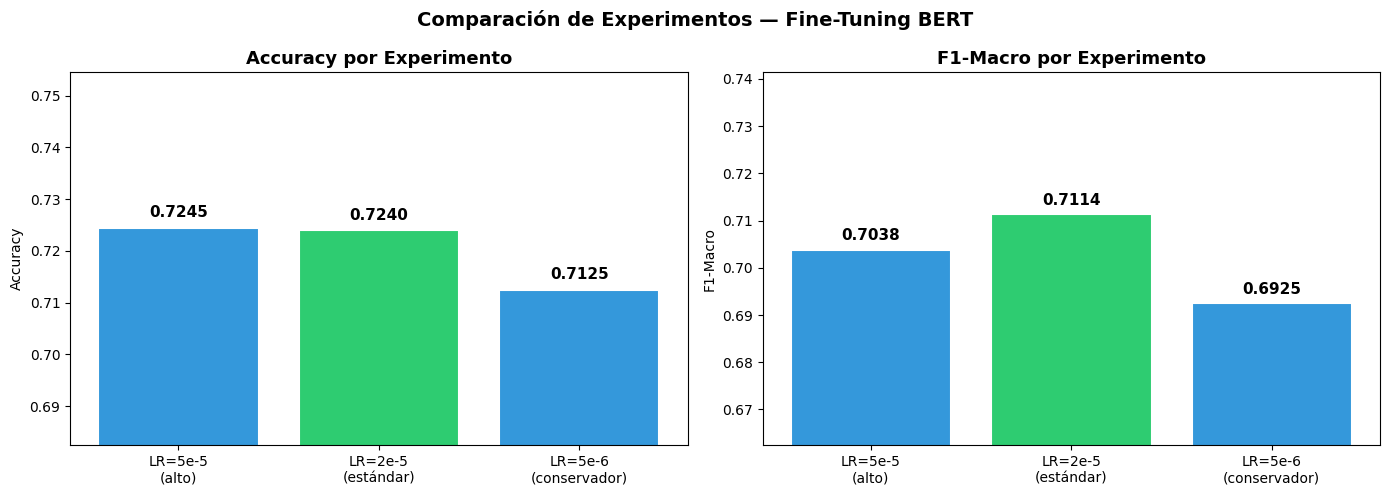

🟢 Barra verde = Mejor modelo (LR=2e-5)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

experimentos = ["LR=5e-5\n(alto)", "LR=2e-5\n(estándar)", "LR=5e-6\n(conservador)"]
acc_vals = [resultados_exp1["eval_accuracy"],
            resultados_exp2["eval_accuracy"],
            resultados_exp3["eval_accuracy"]]
f1_vals  = [resultados_exp1["eval_f1_macro"],
            resultados_exp2["eval_f1_macro"],
            resultados_exp3["eval_f1_macro"]]

# Verde para el mejor, azul para los demás
colores = ['#3498db', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vals, titulo in zip(axes, [acc_vals, f1_vals], ["Accuracy", "F1-Macro"]):
    bars = ax.bar(experimentos, vals, color=colores, edgecolor='white', linewidth=1.5)
    ax.set_title(f"{titulo} por Experimento", fontsize=13, fontweight='bold')
    ax.set_ylabel(titulo)
    ax.set_ylim(min(vals) - 0.03, min(max(vals) + 0.03, 1.0))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{val:.4f}", ha='center', fontsize=11, fontweight='bold')

plt.suptitle("Comparación de Experimentos — Fine-Tuning BERT",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("comparacion_experimentos.png", dpi=150, bbox_inches='tight')
plt.show()
print("🟢 Barra verde = Mejor modelo (LR=2e-5)")

In [ ]:
import pandas as pd

df_resultados = pd.DataFrame({
    "Experimento": [
        "Exp. 1 — LR: 5e-5 (alto)",
        "Exp. 2 — LR: 2e-5 (estándar)",
        "Exp. 3 — LR: 5e-6 (conservador)"
    ],
    "Learning Rate": ["5e-5", "2e-5", "5e-6"],
    "Accuracy": [
        resultados_exp1["eval_accuracy"],
        resultados_exp2["eval_accuracy"],
        resultados_exp3["eval_accuracy"]
    ],
    "F1-Macro": [
        resultados_exp1["eval_f1_macro"],
        resultados_exp2["eval_f1_macro"],
        resultados_exp3["eval_f1_macro"]
    ]
})

print("📊 TABLA COMPARATIVA — VALIDACIÓN")
print("=" * 60)
print(df_resultados.to_string(index=False))
print("=" * 60)

# Identificar el mejor
mejor_idx = df_resultados["F1-Macro"].idxmax()
print(f"\n🏆 Mejor modelo: {df_resultados.loc[mejor_idx, 'Experimento']}")
print(f"   F1-Macro : {df_resultados.loc[mejor_idx, 'F1-Macro']:.4f}")
print(f"   Accuracy : {df_resultados.loc[mejor_idx, 'Accuracy']:.4f}")

📊 TABLA COMPARATIVA — VALIDACIÓN
                    Experimento Learning Rate  Accuracy  F1-Macro
       Exp. 1 — LR: 5e-5 (alto)          5e-5    0.7245  0.703818
   Exp. 2 — LR: 2e-5 (estándar)          2e-5    0.7240  0.711390
Exp. 3 — LR: 5e-6 (conservador)          5e-6    0.7125  0.692462

🏆 Mejor modelo: Exp. 2 — LR: 2e-5 (estándar)
   F1-Macro : 0.7114
   Accuracy : 0.7240
